In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── Config ──
PARTICIPANT = "kokosnoot"
DATA_DIR = Path(f"../data/wearables/{PARTICIPANT}/processed")

# Load data
traces = pd.read_csv(DATA_DIR / "session_traces_all.csv", parse_dates=["timestamp_utc"])
sessions = pd.read_csv(DATA_DIR / "session_biometrics.csv")
s = sessions[sessions["stress_points"] > 0].copy()
s["mood_delta"] = s["mood_after_score"] - s["mood_before_score"]

# Palette
ENERGY_CLR = "#fb923c"
CALM_CLR   = "#22d3ee"
STRESS_CLR = "#fb923c"
HR_CLR     = "#f472b6"
BB_CLR     = "#34d399"

dates = sorted(traces["session_date"].unique())
print(f"{len(dates)} sessions loaded: {s['playlist'].value_counts().to_dict()}")

9 sessions loaded: {'Energy': 5, 'Calm': 4}


## 1. Single session trace

Pick any session and see stress, HR, and Body Battery minute by minute.  
The shaded region marks the playlist.

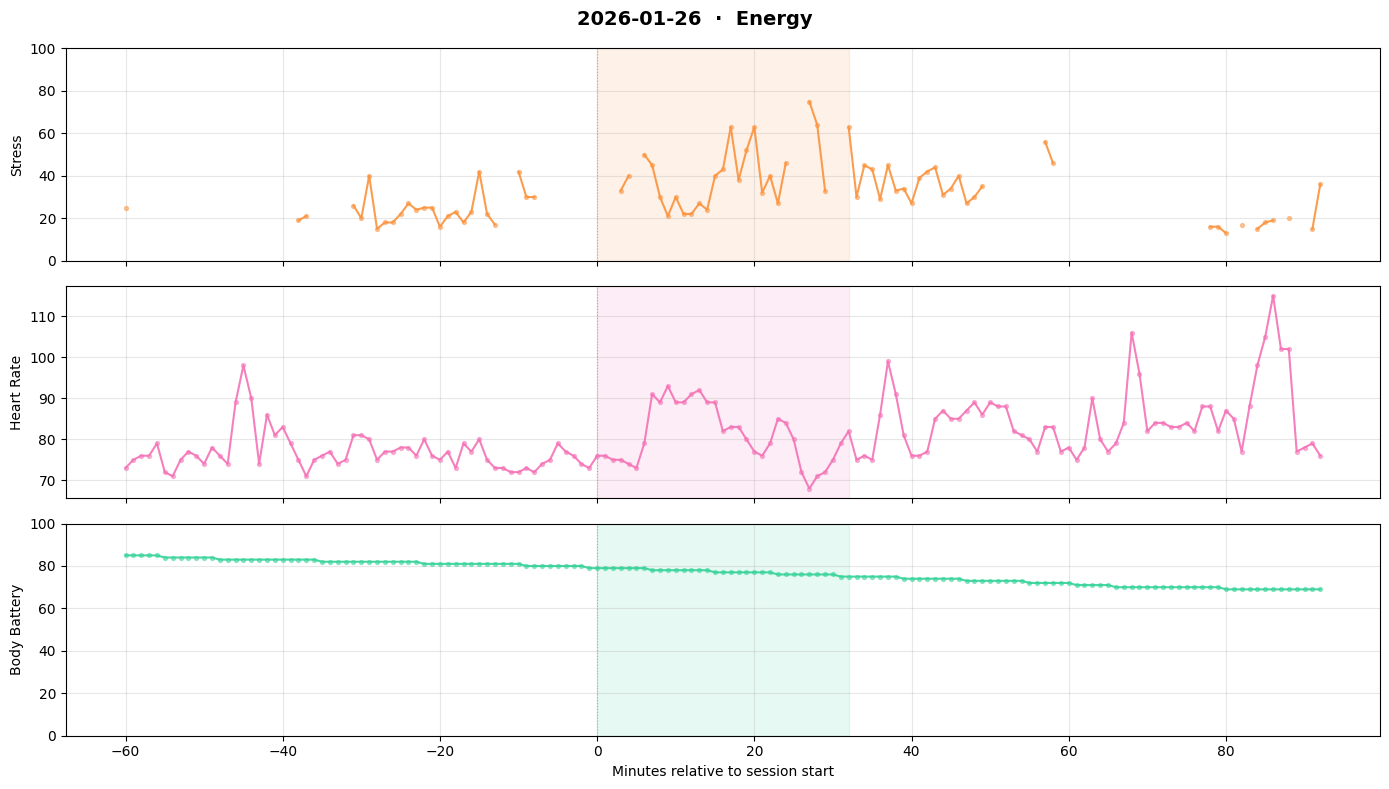

In [16]:
def plot_session(traces_df, session_date, figsize=(14, 8)):
    """Plot stress, HR, and Body Battery for a single session."""
    t = traces_df[traces_df["session_date"] == session_date].copy()
    if t.empty:
        print(f"No data for {session_date}")
        return

    playlist = t["playlist"].iloc[0]
    x = t["minutes_relative"]

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    fig.suptitle(f"{session_date}  ·  {playlist}", fontsize=14, fontweight="bold")

    metrics = [
        ("stress",       "Stress",        STRESS_CLR, (0, 100)),
        ("heart_rate",   "Heart Rate",    HR_CLR,     None),
        ("body_battery", "Body Battery",  BB_CLR,     (0, 100)),
    ]

    for ax, (col, label, color, ylim) in zip(axes, metrics):
        if col in t.columns:
            ax.plot(x, t[col], color=color, lw=1.5, alpha=0.9)
            ax.scatter(x[t[col].notna()], t.loc[t[col].notna(), col],
                       color=color, s=8, alpha=0.5, zorder=3)
        during = t[t["phase"] == "during"]["minutes_relative"]
        if len(during):
            ax.axvspan(during.min(), during.max(), alpha=0.12, color=color)
        ax.axvline(0, color="grey", ls=":", lw=0.8, alpha=0.5)
        ax.set_ylabel(label, fontsize=10)
        if ylim:
            ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Minutes relative to session start", fontsize=10)
    plt.tight_layout()
    plt.show()

# Show first session
plot_session(traces, dates[0])

## 2. Browse all sessions

Grid view — one row per session, three columns.

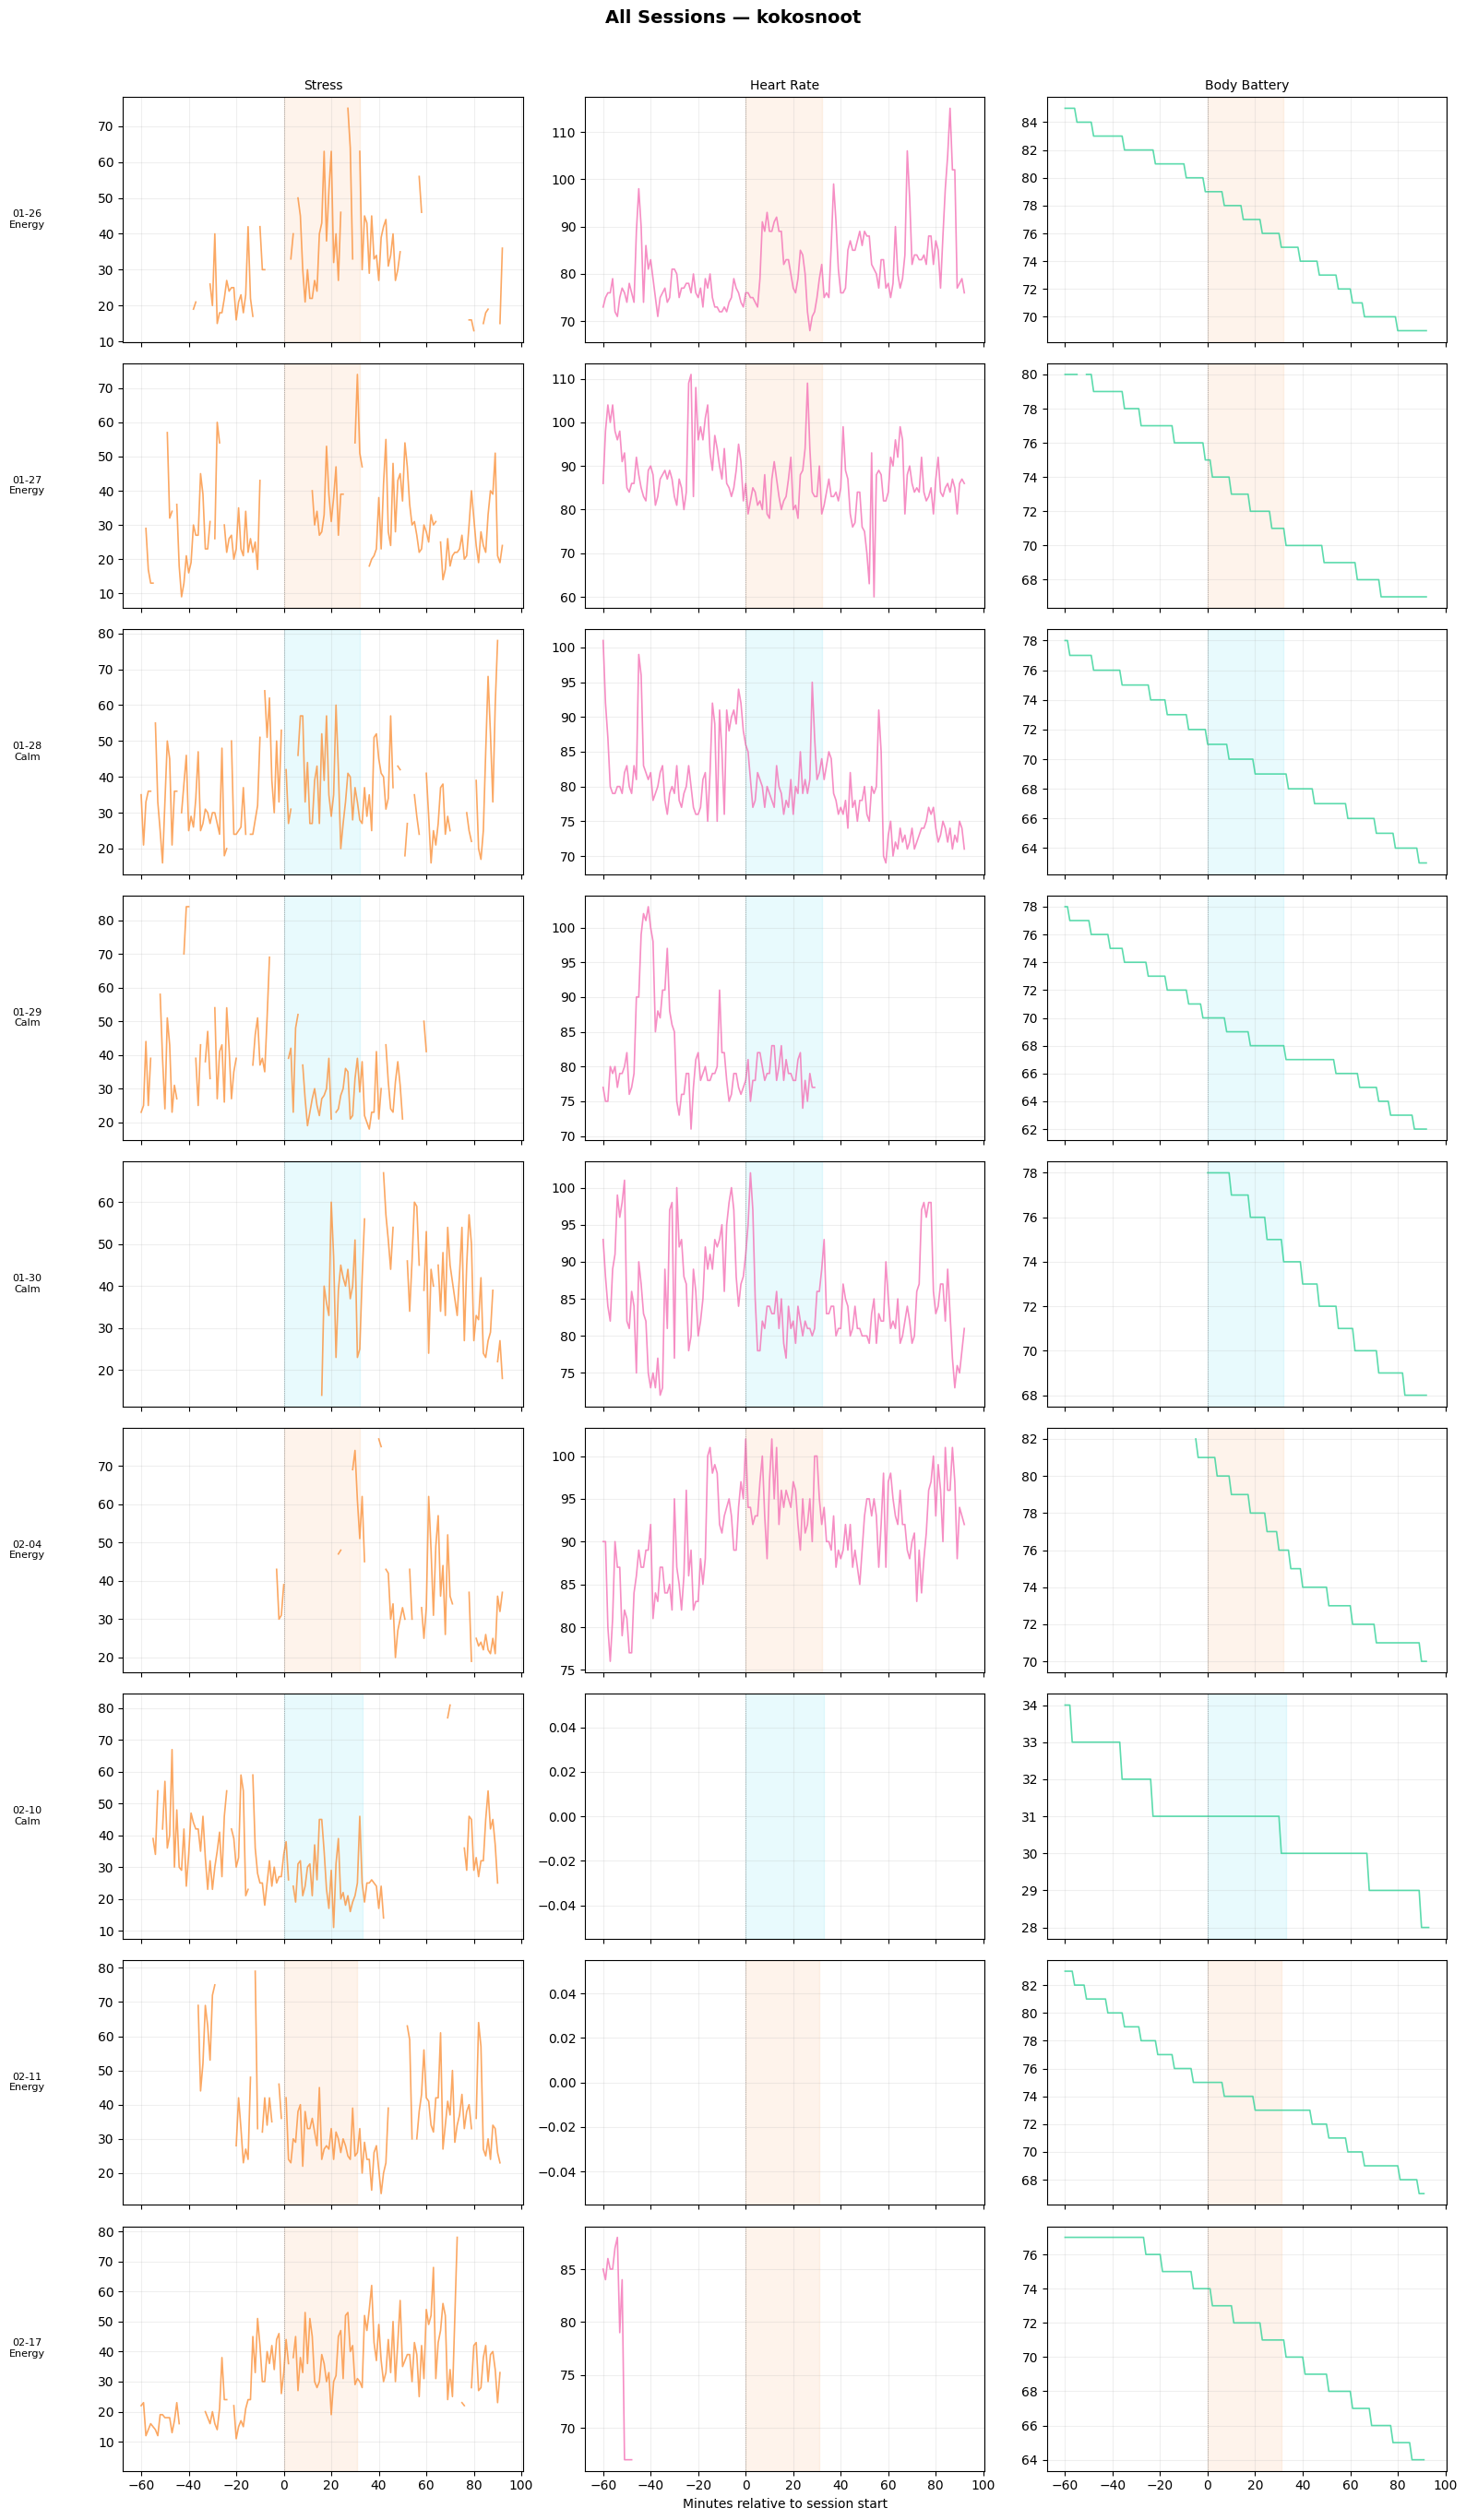

In [17]:
n = len(dates)
fig, axes = plt.subplots(n, 3, figsize=(16, 3 * n), sharex=True)
if n == 1:
    axes = axes.reshape(1, -1)

for i, date in enumerate(dates):
    t = traces[traces["session_date"] == date]
    x = t["minutes_relative"]
    playlist = t["playlist"].iloc[0]
    pl_color = ENERGY_CLR if playlist == "Energy" else CALM_CLR

    for j, (col, color) in enumerate([
        ("stress", STRESS_CLR), ("heart_rate", HR_CLR), ("body_battery", BB_CLR)
    ]):
        ax = axes[i, j]
        if col in t.columns:
            ax.plot(x, t[col], color=color, lw=1.2, alpha=0.8)
        during = t[t["phase"] == "during"]["minutes_relative"]
        if len(during):
            ax.axvspan(during.min(), during.max(), alpha=0.1, color=pl_color)
        ax.axvline(0, color="grey", ls=":", lw=0.5)
        ax.grid(True, alpha=0.2)
        if i == 0:
            ax.set_title(["Stress", "Heart Rate", "Body Battery"][j], fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{date[5:]}\n{playlist}", fontsize=8,
                          rotation=0, labelpad=55, va="center")

axes[-1, 1].set_xlabel("Minutes relative to session start")
plt.suptitle(f"All Sessions — {PARTICIPANT}", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Average trace by playlist type

Mean ± standard deviation across all Energy vs all Calm sessions.  
Grey band = approximate playlist duration.

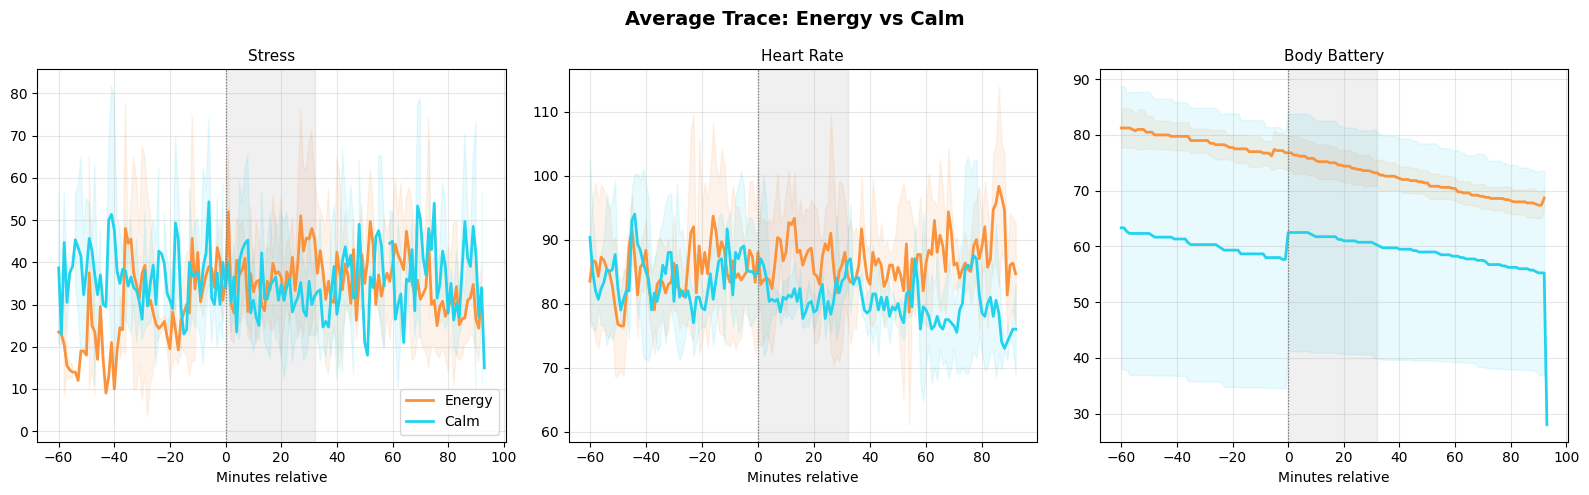

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for playlist, color in [("Energy", ENERGY_CLR), ("Calm", CALM_CLR)]:
    sub = traces[traces["playlist"] == playlist]
    grouped = sub.groupby("minutes_relative")

    for j, (col, label) in enumerate([
        ("stress", "Stress"), ("heart_rate", "Heart Rate"), ("body_battery", "Body Battery")
    ]):
        ax = axes[j]
        mean = grouped[col].mean()
        std  = grouped[col].std()
        ax.plot(mean.index, mean.values, color=color, lw=2, label=playlist)
        ax.fill_between(mean.index, mean - std, mean + std, color=color, alpha=0.1)
        ax.axvline(0, color="grey", ls=":", lw=0.8)
        ax.axvspan(0, 32, alpha=0.06, color="grey")
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Minutes relative")
        ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=10)
plt.suptitle("Average Trace: Energy vs Calm", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Mood vs physiology

Do subjective mood changes align with objective stress/BB changes?

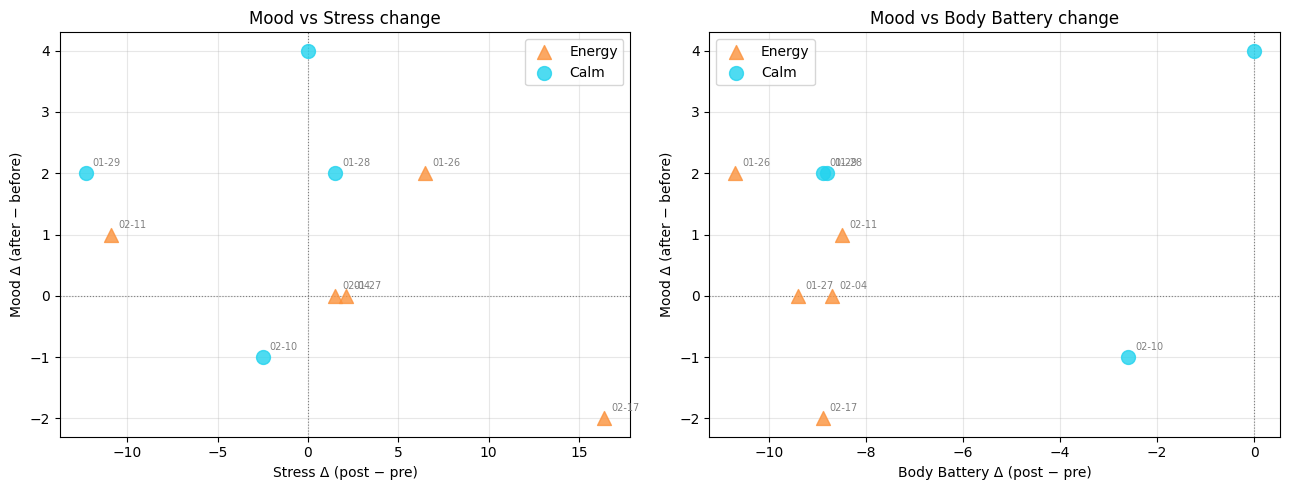

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for playlist, color, marker in [("Energy", ENERGY_CLR, "^"), ("Calm", CALM_CLR, "o")]:
    sub = s[s["playlist"] == playlist]
    for ax_i, x_col in enumerate(["stress_delta", "bb_delta_full"]):
        ax = axes[ax_i]
        if len(sub):
            ax.scatter(sub[x_col].fillna(0), sub["mood_delta"],
                       c=color, marker=marker, s=100, alpha=0.8, label=playlist, zorder=5)
            for _, r in sub.iterrows():
                ax.annotate(r["date"][5:], (r[x_col] or 0, r["mood_delta"]),
                            fontsize=7, color="grey", xytext=(5, 5), textcoords="offset points")

for ax, xlabel in zip(axes, ["Stress Δ (post − pre)", "Body Battery Δ (post − pre)"]):
    ax.axhline(0, color="grey", ls=":", lw=0.8)
    ax.axvline(0, color="grey", ls=":", lw=0.8)
    ax.set_xlabel(xlabel); ax.set_ylabel("Mood Δ (after − before)")
    ax.grid(True, alpha=0.3); ax.legend()

axes[0].set_title("Mood vs Stress change")
axes[1].set_title("Mood vs Body Battery change")
plt.tight_layout()
plt.show()

## 5. Session summary table

In [34]:
cols = [
    "date", "playlist", "start_local", "end_local",
    "mood_before", "mood_before_score", "mood_after", "mood_after_score",
    "pre_stress_mean", "stress_mean", "post_stress_mean", "stress_delta",
    "hr_mean", "bb_start", "bb_end", "bb_delta",
]
sessions[cols].round(1)

,date,playlist,start_local,end_local,mood_before,mood_before_score,mood_after,mood_after_score,pre_stress_mean,stress_mean,post_stress_mean,stress_delta,hr_mean,bb_start,bb_end,bb_delta
0,2026-01-26,Energy,07:22,07:54,Moe of ongemotiveerd,5,Happy,7,24.4,40.9,30.9,6.5,80.8,79.0,75.0,-4.0
1,2026-01-27,Energy,08:26,08:58,Gestresseerd of gespannen,5,Neutraal,5,27.5,42.5,29.6,2.1,85.1,75.0,71.0,-4.0
2,2026-01-28,Calm,08:37,09:09,Neutraal,6,Neutraal,8,34.1,37.9,35.6,1.5,80.7,71.0,69.0,-2.0
3,2026-01-29,Calm,09:07,09:39,Moe of ongemotiveerd,5,gemotiveerd,7,42.3,30.3,30.1,-12.3,79.1,70.0,68.0,-2.0
4,2026-01-30,Calm,08:10,08:42,Gestresseerd of gespannen,4,Neutraal,8,NaN,41.1,41.7,NaN,83.9,78.0,74.0,-4.0
5,2026-02-04,Energy,07:55,08:27,Neutraal,7,happy - gemotiveerd,7,34.7,55.6,36.2,1.5,94.9,81.0,76.0,-5.0
6,2026-02-10,Calm,16:53,17:26,Gestresseerd of gespannen,7,Gestresseerd of gespannen,6,37.1,27.3,34.6,-2.5,NaN,31.0,30.0,-1.0
7,2026-02-11,Energy,07:35,08:06,Moe of ongemotiveerd,6,Neutraal,7,45.9,30.4,35.0,-10.9,NaN,75.0,73.0,-2.0
8,2026-02-17,Energy,10:28,10:59,Neutraal,8,gemotiveerd,6,23.5,37.3,39.9,16.4,NaN,74.0,71.0,-3.0
9,2026-02-24,Energy,16:40,17:13,Moe en gespannen...,7,Neutraal,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Stress variability per session

The mean hides a lot. A session with mean stress 35 could be a flat line  
or wild swings between 10 and 75. Box plots show the full spread.  

**Hypothesis:** Energy playlists create more variability (peaks and valleys),  
Calm playlists produce smoother, more uniform stress.

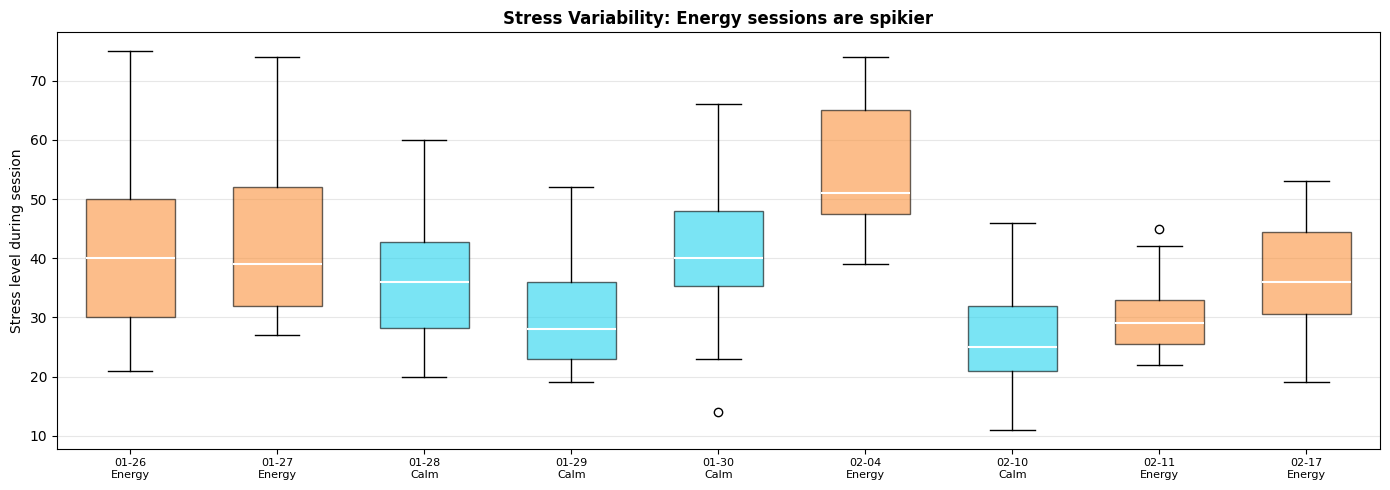

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

box_data = []
box_labels = []
box_colors = []

for date in dates:
    t = traces[(traces["session_date"] == date) & (traces["phase"] == "during")]
    vals = t["stress"].dropna().values
    if len(vals):
        box_data.append(vals)
        pl = t["playlist"].iloc[0]
        box_labels.append(f"{date[5:]}\n{pl}")
        box_colors.append(ENERGY_CLR if pl == "Energy" else CALM_CLR)

bp = ax.boxplot(box_data, patch_artist=True, widths=0.6,
                medianprops=dict(color="white", lw=1.5))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xticklabels(box_labels, fontsize=8)
ax.set_ylabel("Stress level during session")
ax.set_title("Stress Variability: Energy sessions are spikier", fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Within-session trajectory

Does the effect build over the 30 minutes, or is it immediate?  
Compare first 5 minutes vs last 5 minutes of each session.

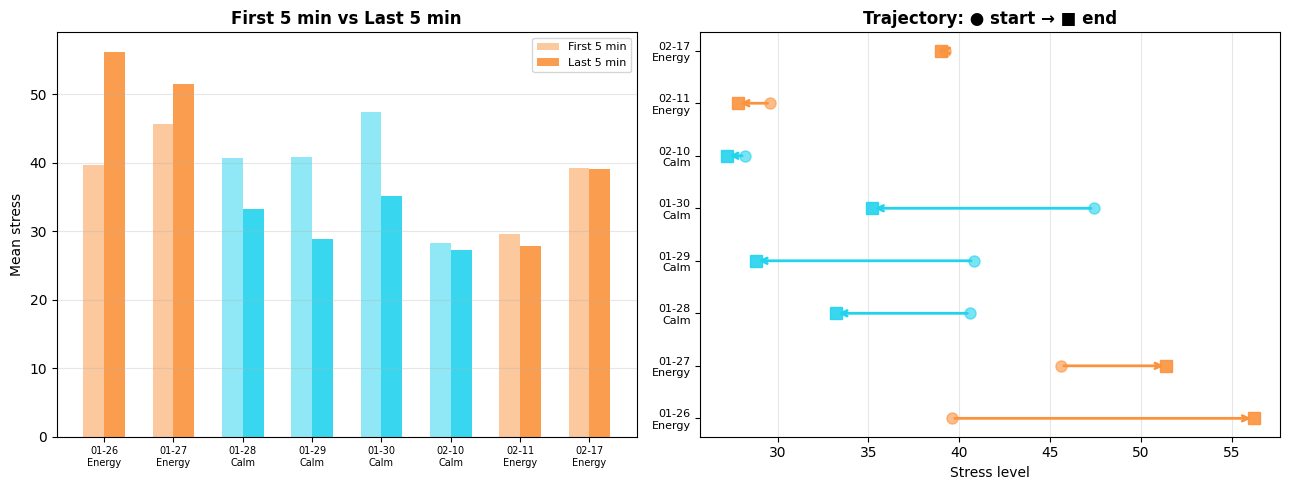

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

first5, last5, colors, labels = [], [], [], []
for date in dates:
    t = traces[(traces["session_date"] == date) & (traces["phase"] == "during")]
    t = t.sort_values("minutes_relative")
    stress = t["stress"].dropna()
    if len(stress) < 10:
        continue
    f = stress.head(5).mean()
    l = stress.tail(5).mean()
    pl = t["playlist"].iloc[0]
    first5.append(f); last5.append(l)
    colors.append(ENERGY_CLR if pl == "Energy" else CALM_CLR)
    labels.append(f"{date[5:]}\n{pl}")

# Paired bar chart
x = np.arange(len(first5))
ax = axes[0]
ax.bar(x - 0.15, first5, 0.3, color=[c for c in colors], alpha=0.5, label="First 5 min")
ax.bar(x + 0.15, last5,  0.3, color=[c for c in colors], alpha=0.9, label="Last 5 min")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("Mean stress"); ax.set_title("First 5 min vs Last 5 min", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, axis="y", alpha=0.3)

# Arrow plot: direction of change
ax = axes[1]
for i, (f, l, c, lab) in enumerate(zip(first5, last5, colors, labels)):
    ax.annotate("", xy=(l, i), xytext=(f, i),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.plot(f, i, "o", color=c, ms=8, alpha=0.6)
    ax.plot(l, i, "s", color=c, ms=8, alpha=0.9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Stress level"); ax.set_title("Trajectory: ● start → ■ end", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Recovery curve

How quickly does stress return to the pre-session baseline after the music stops?  
Each line is one session, normalised to its own pre-session mean (0 = baseline).

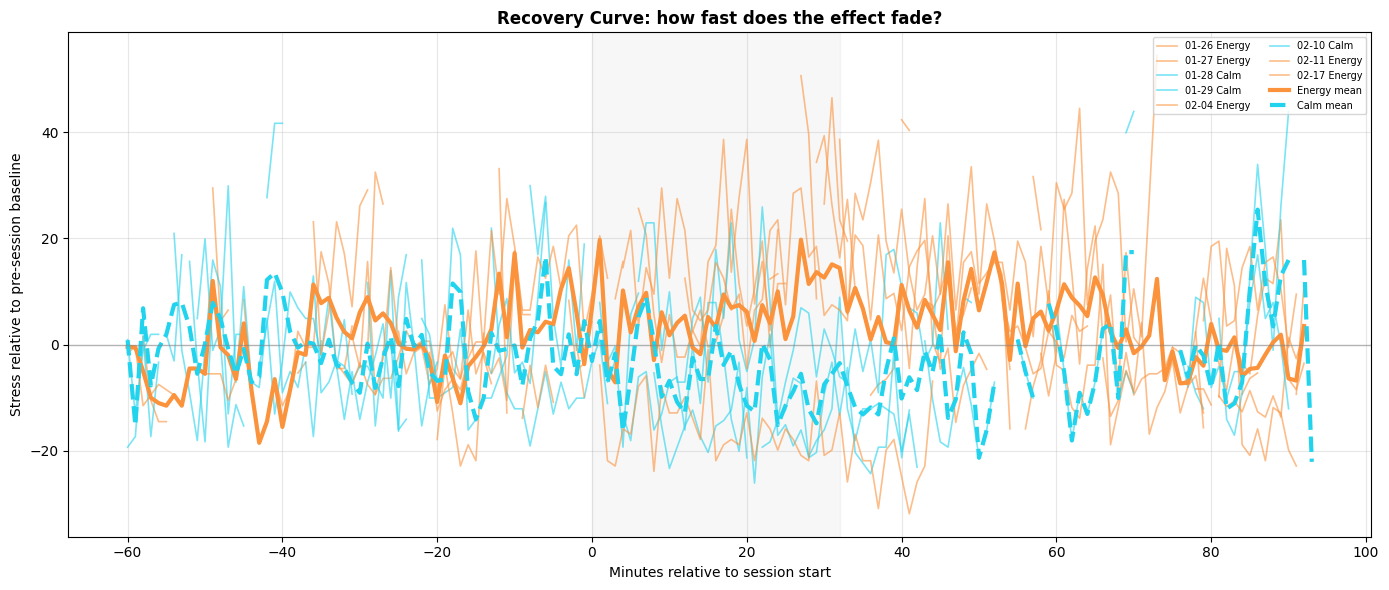

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

for date in dates:
    t = traces[traces["session_date"] == date].copy()
    pre_mean = t[t["phase"] == "pre"]["stress"].mean()
    if np.isnan(pre_mean):
        continue

    pl = t["playlist"].iloc[0]
    color = ENERGY_CLR if pl == "Energy" else CALM_CLR

    # Normalise stress to pre-session baseline
    t["stress_norm"] = t["stress"] - pre_mean
    ax.plot(t["minutes_relative"], t["stress_norm"],
            color=color, lw=1.2, alpha=0.6, label=f"{date[5:]} {pl}")

# Add mean lines per playlist
for pl, color, ls in [("Energy", ENERGY_CLR, "-"), ("Calm", CALM_CLR, "--")]:
    sub = traces[traces["playlist"] == pl].copy()
    # compute per-session baseline and normalise
    normed = []
    for date in sub["session_date"].unique():
        st = sub[sub["session_date"] == date].copy()
        pre = st[st["phase"] == "pre"]["stress"].mean()
        if not np.isnan(pre):
            st["stress_norm"] = st["stress"] - pre
            normed.append(st)
    if normed:
        combined = pd.concat(normed)
        mean = combined.groupby("minutes_relative")["stress_norm"].mean()
        ax.plot(mean.index, mean.values, color=color, lw=3, ls=ls, label=f"{pl} mean")

ax.axhline(0, color="grey", ls="-", lw=1, alpha=0.5)
ax.axvspan(0, 32, alpha=0.06, color="grey")
ax.set_xlabel("Minutes relative to session start")
ax.set_ylabel("Stress relative to pre-session baseline")
ax.set_title("Recovery Curve: how fast does the effect fade?", fontweight="bold")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Baseline-adjusted response

Raw stress values are misleading if the participant starts a session already stressed.  
Subtracting pre-session baseline reveals the **net effect** of the music.

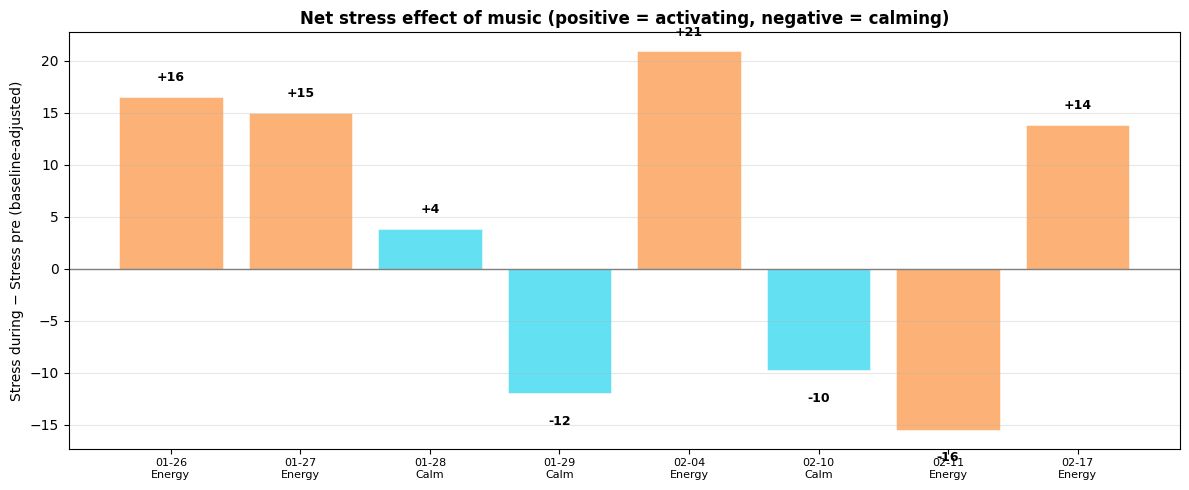

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

x_vals, y_vals, colors_list, label_list = [], [], [], []

for _, r in s.iterrows():
    pre = r["pre_stress_mean"]
    dur = r["stress_mean"]
    if pd.isna(pre) or pd.isna(dur):
        continue
    delta = dur - pre
    pl = r["playlist"]
    x_vals.append(r["date"][5:] + "\n" + pl)
    y_vals.append(delta)
    colors_list.append(ENERGY_CLR if pl == "Energy" else CALM_CLR)

bars = ax.bar(range(len(x_vals)), y_vals, color=colors_list, alpha=0.7, edgecolor="white", lw=0.5)
ax.axhline(0, color="grey", lw=1)
ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_vals, fontsize=8)
ax.set_ylabel("Stress during − Stress pre (baseline-adjusted)")
ax.set_title("Net stress effect of music (positive = activating, negative = calming)", fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

# Annotate values
for i, v in enumerate(y_vals):
    ax.text(i, v + (1.5 if v >= 0 else -3), f"{v:+.0f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 10. Session heatmap

Every session as a single horizontal strip, coloured by stress level minute-by-minute.  
Sessions stacked vertically — gives you the full picture at a glance.  
Vertical white lines mark session start and end.

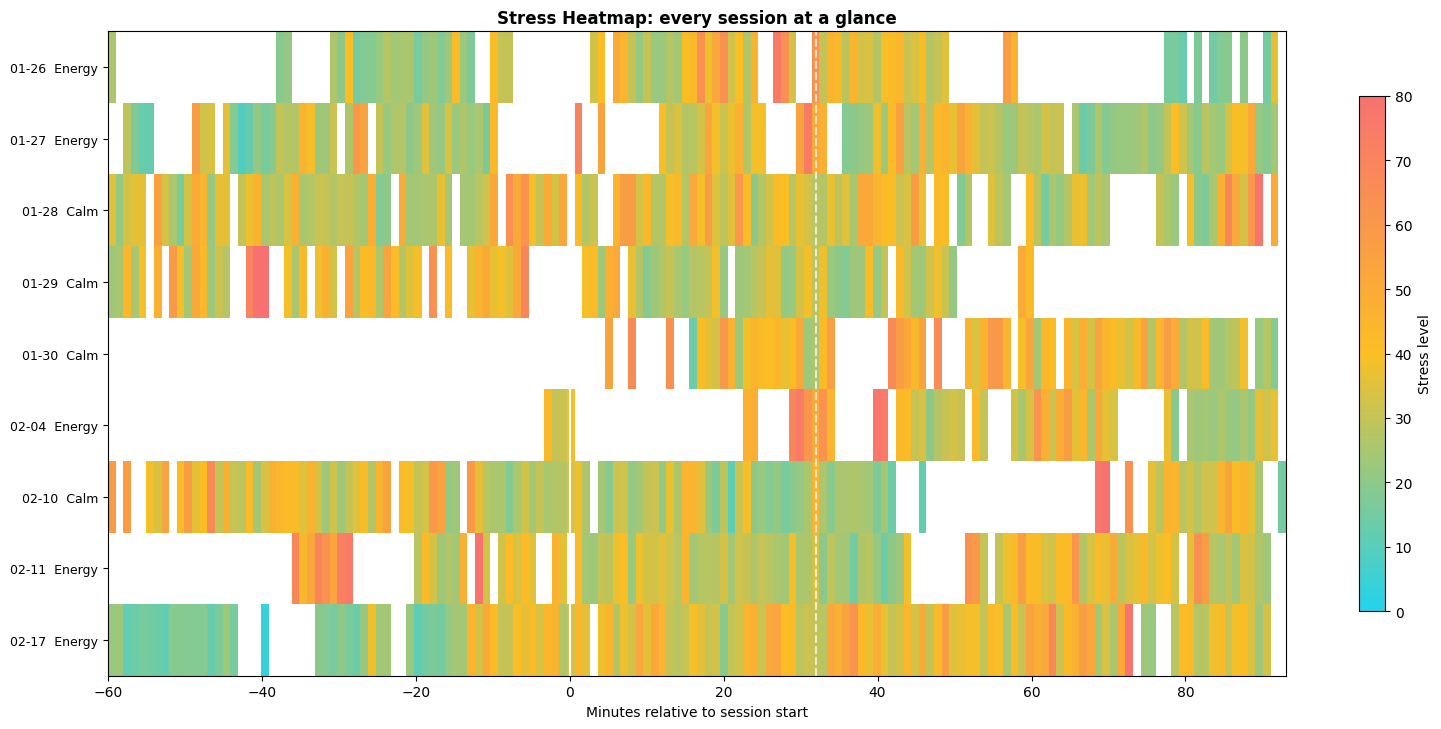

In [27]:
fig, ax = plt.subplots(figsize=(16, 0.6 * len(dates) + 2))

# Build a matrix: rows = sessions, cols = minutes
all_minutes = sorted(traces["minutes_relative"].unique())
matrix = []
ylabels = []

for date in dates:
    t = traces[traces["session_date"] == date]
    pl = t["playlist"].iloc[0]
    # Reindex to consistent minute grid
    row = t.set_index("minutes_relative")["stress"].reindex(all_minutes)
    matrix.append(row.values)
    ylabels.append(f"{date[5:]}  {pl}")

matrix = np.array(matrix)

# Custom colormap: low stress = blue, high = red
cmap = mcolors.LinearSegmentedColormap.from_list("stress", ["#22d3ee", "#fbbf24", "#f87171"])

im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=80,
               extent=[min(all_minutes), max(all_minutes), len(dates) - 0.5, -0.5])

# Mark session boundaries
ax.axvline(0, color="white", lw=1.5, ls="-")
ax.axvline(32, color="white", lw=1.5, ls="--", alpha=0.7)  # ~avg duration

ax.set_yticks(range(len(dates)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel("Minutes relative to session start")
ax.set_title("Stress Heatmap: every session at a glance", fontweight="bold")

plt.colorbar(im, ax=ax, label="Stress level", shrink=0.8)
plt.tight_layout()
plt.show()

---

## Baseline comparisons

Everything above compares pre→during→post *within* a session.  
But what's **normal** for this participant? The full minute-level dataset  
(~54k stress readings across 38 days) gives us a baseline to compare against.

Key questions:
- Is session stress different from what the participant *normally* experiences at that time of day?
- Does the circadian rhythm explain some of what we're seeing?
- Are session days different from non-session days?

In [28]:
# Load full minute-level data
stress_full = pd.read_csv(DATA_DIR / "garmin_minute_stress.csv", parse_dates=["timestamp"])
hr_full = pd.read_csv(DATA_DIR / "garmin_minute_hr.csv", parse_dates=["timestamp"])

# Tag session vs non-session days
session_dates = set(traces["session_date"].unique())
stress_full["date"] = stress_full["timestamp"].dt.date.astype(str)
stress_full["hour_utc"] = stress_full["timestamp"].dt.hour
stress_full["is_session_day"] = stress_full["date"].isin(session_dates)

hr_full["date"] = hr_full["timestamp"].dt.date.astype(str)
hr_full["hour_utc"] = hr_full["timestamp"].dt.hour

non_session_stress = stress_full[~stress_full["is_session_day"]]
print(f"Baseline: {non_session_stress['date'].nunique()} non-session days, "
      f"{len(non_session_stress)} stress readings")

Baseline: 30 non-session days, 41781 stress readings


## 11. Circadian stress profile

The participant's typical stress pattern across the day, built from non-session days.  
This is the **expected** stress at any given hour — the null hypothesis.

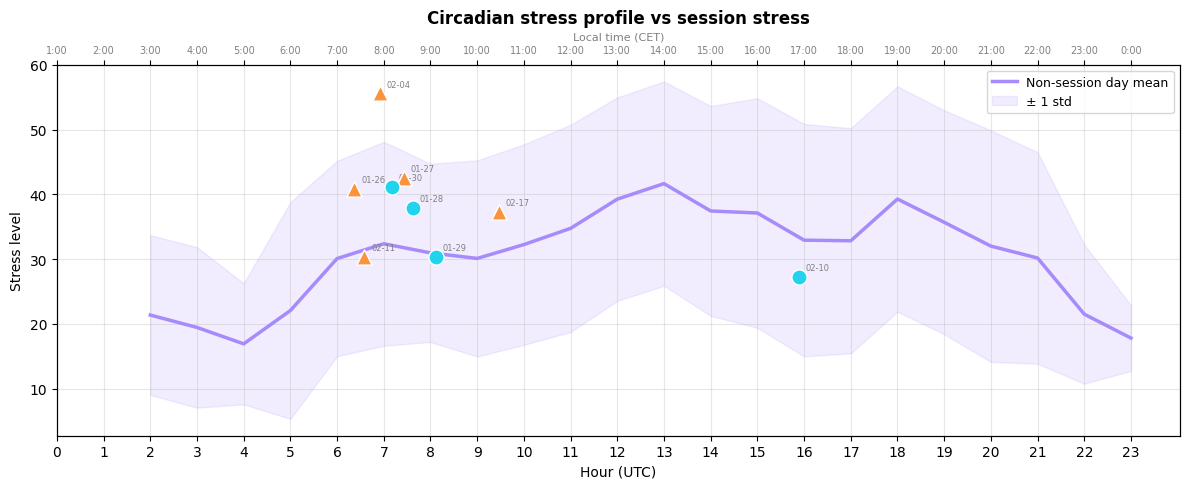

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

# Hourly profile from non-session days
hourly = non_session_stress.groupby("hour_utc")["stress"].agg(["mean", "std", "count"])
hourly = hourly[hourly["count"] >= 10]  # only hours with enough data

ax.plot(hourly.index, hourly["mean"], color="#a78bfa", lw=2.5, label="Non-session day mean")
ax.fill_between(hourly.index,
                hourly["mean"] - hourly["std"],
                hourly["mean"] + hourly["std"],
                color="#a78bfa", alpha=0.15, label="± 1 std")

# Overlay session times as points
for _, r in s.iterrows():
    # Convert local start time to UTC hour
    h, m = map(int, r["start_local"].split(":"))
    utc_hour = h - 1  # CET → UTC
    pl = r["playlist"]
    color = ENERGY_CLR if pl == "Energy" else CALM_CLR
    marker = "^" if pl == "Energy" else "o"
    ax.scatter(utc_hour + m/60, r["stress_mean"], color=color, marker=marker,
               s=120, zorder=5, edgecolors="white", lw=1)
    ax.annotate(r["date"][5:], (utc_hour + m/60, r["stress_mean"]),
                fontsize=6, color="grey", xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Stress level")
ax.set_title("Circadian stress profile vs session stress", fontweight="bold")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Add local time labels on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(range(0, 24))
ax2.set_xticklabels([f"{(h+1)%24}:00" for h in range(24)], fontsize=7, color="grey")
ax2.set_xlabel("Local time (CET)", fontsize=8, color="grey")

plt.tight_layout()
plt.show()

## 12. Session trace vs time-of-day baseline

For each session, overlay the minute-level trace against what stress  
*typically* looks like at that exact time of day on non-session days.  

If the music has an effect, the session trace should **diverge** from the  
baseline band during/after the playlist.

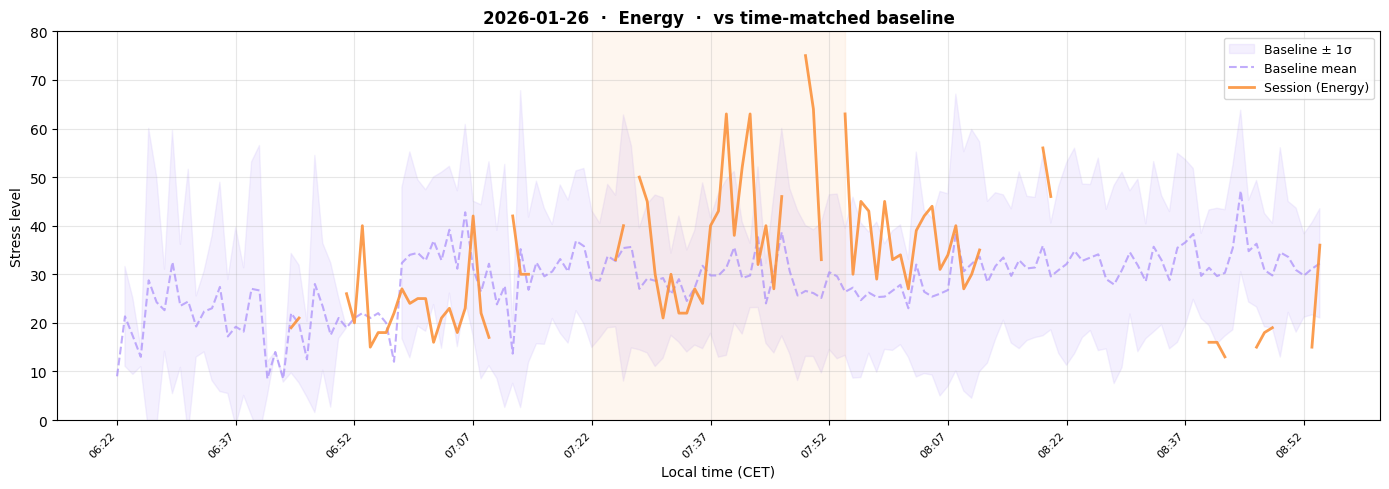

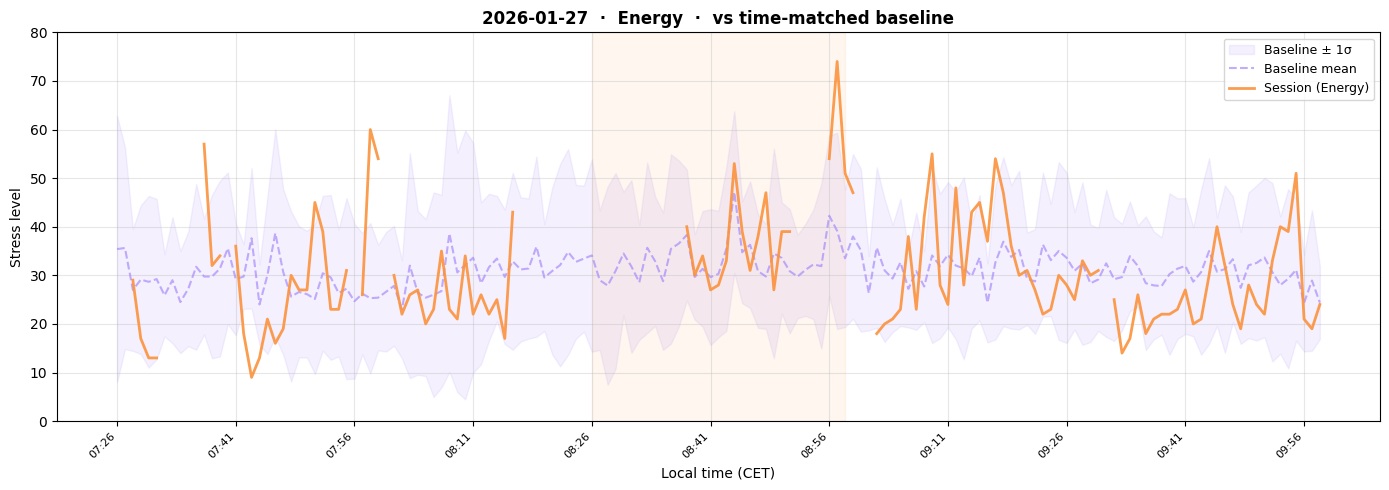

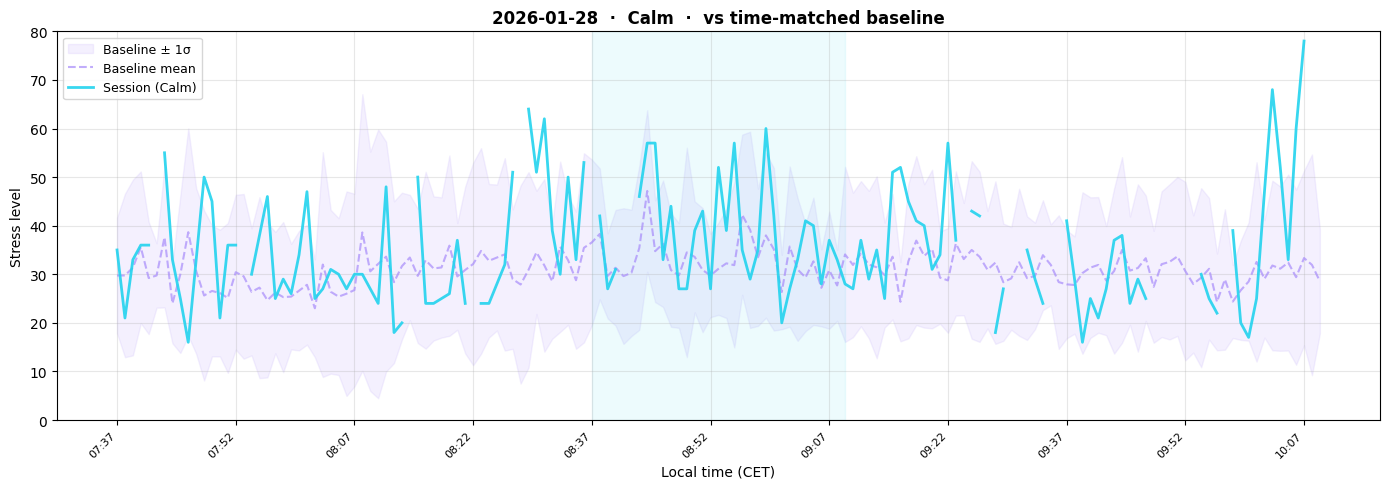

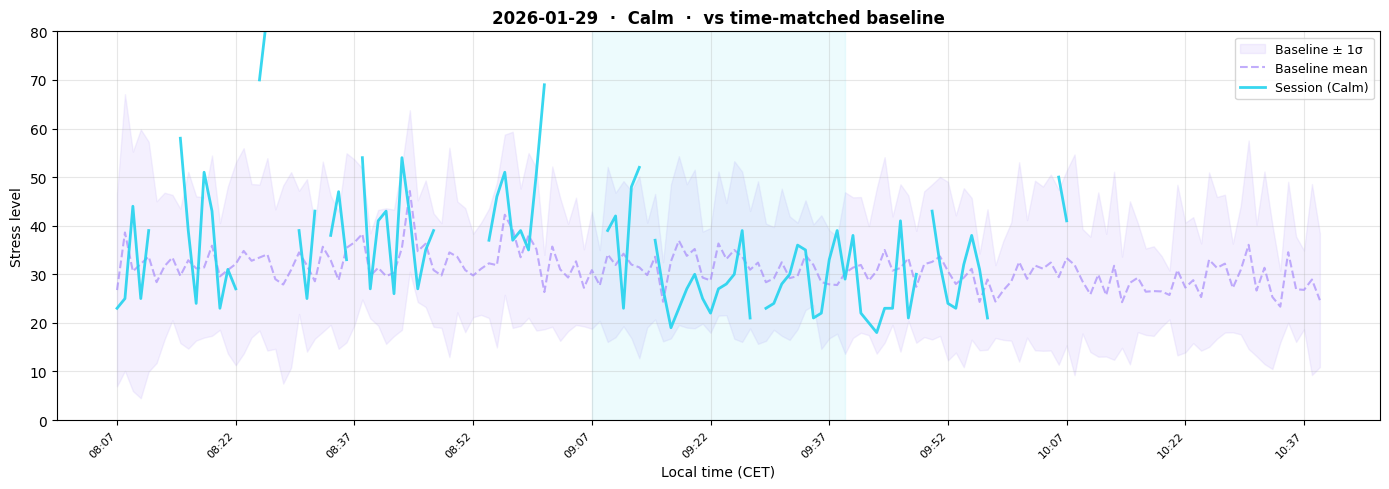

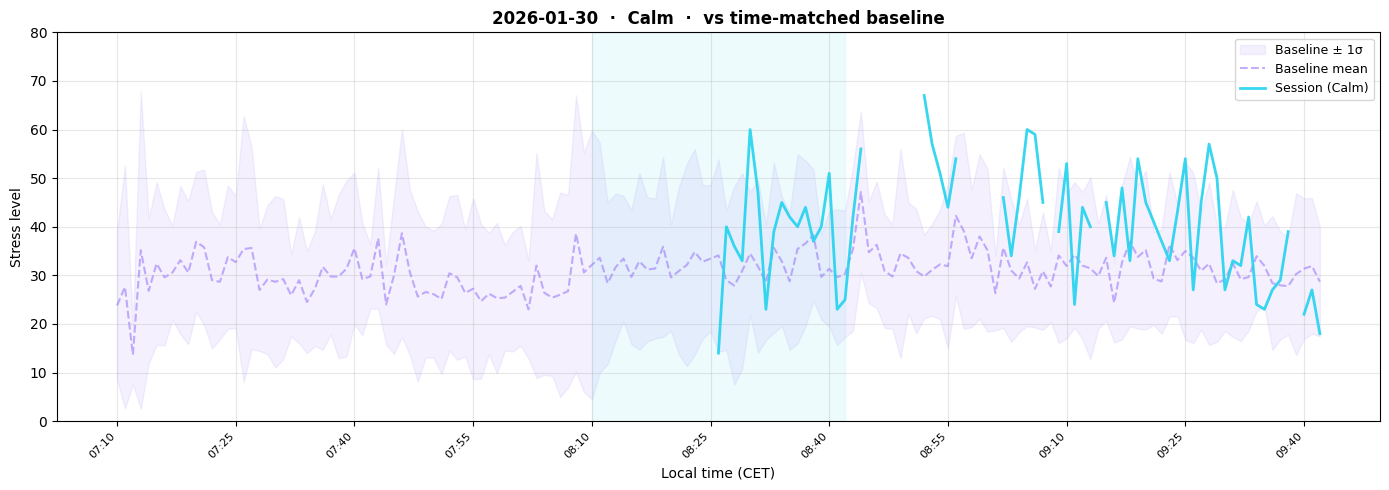

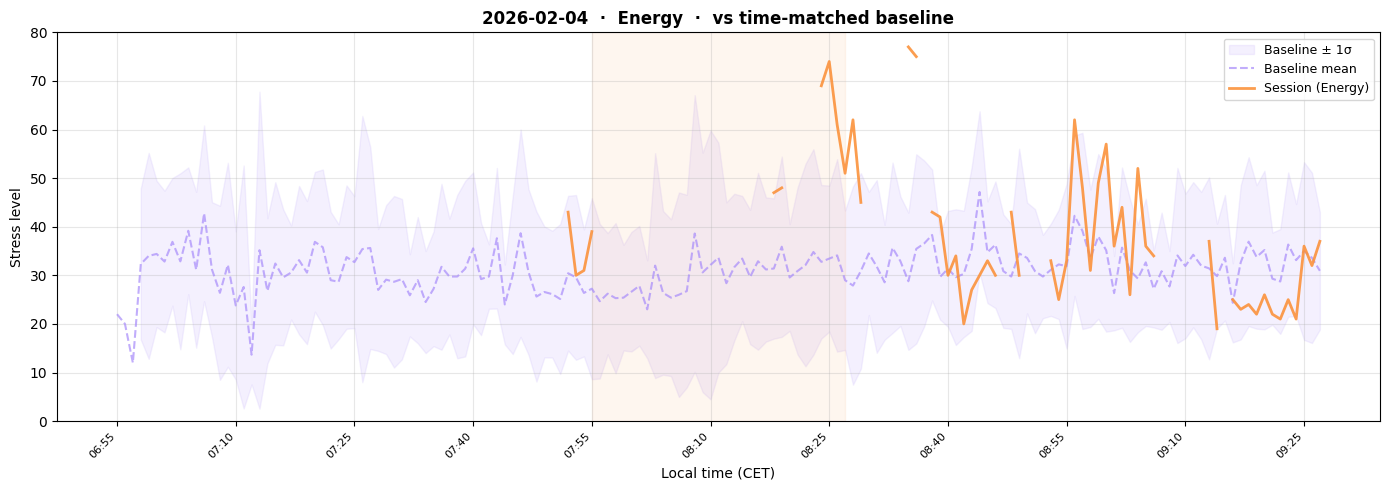

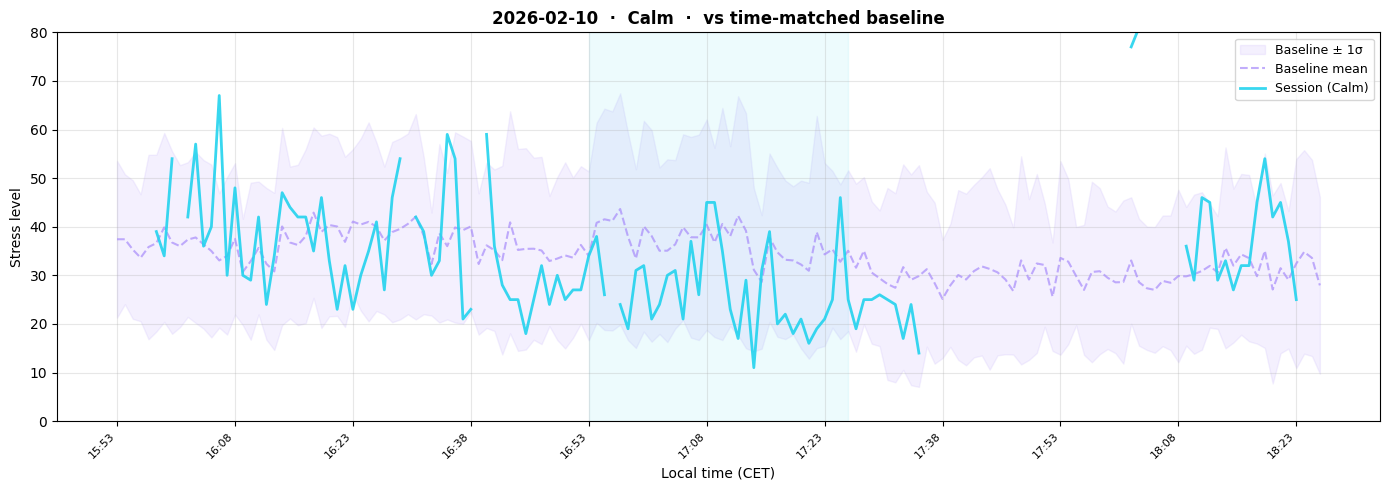

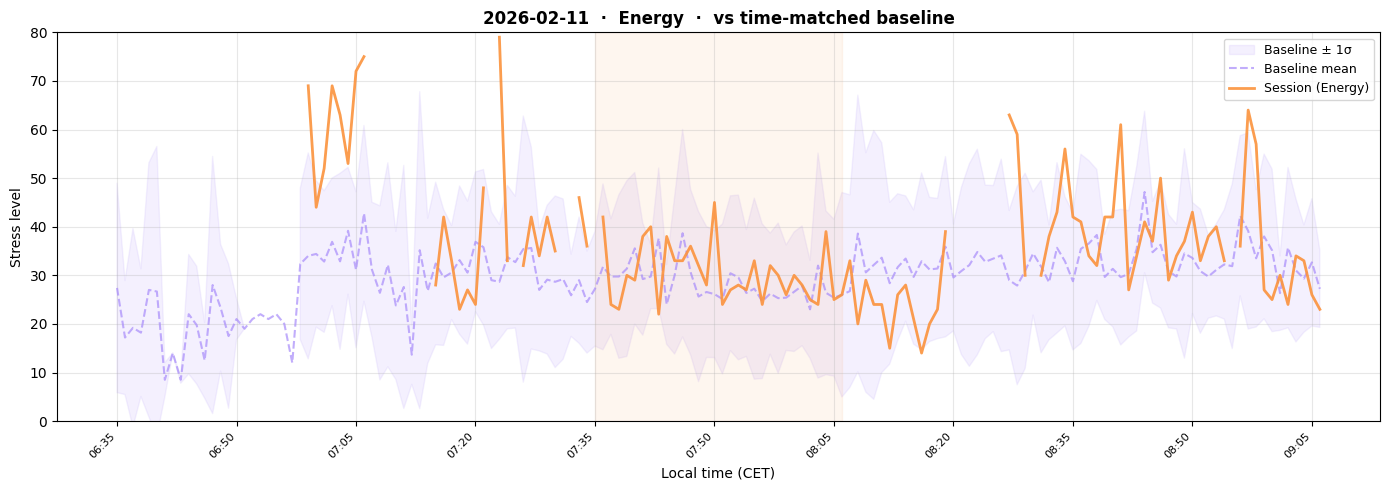

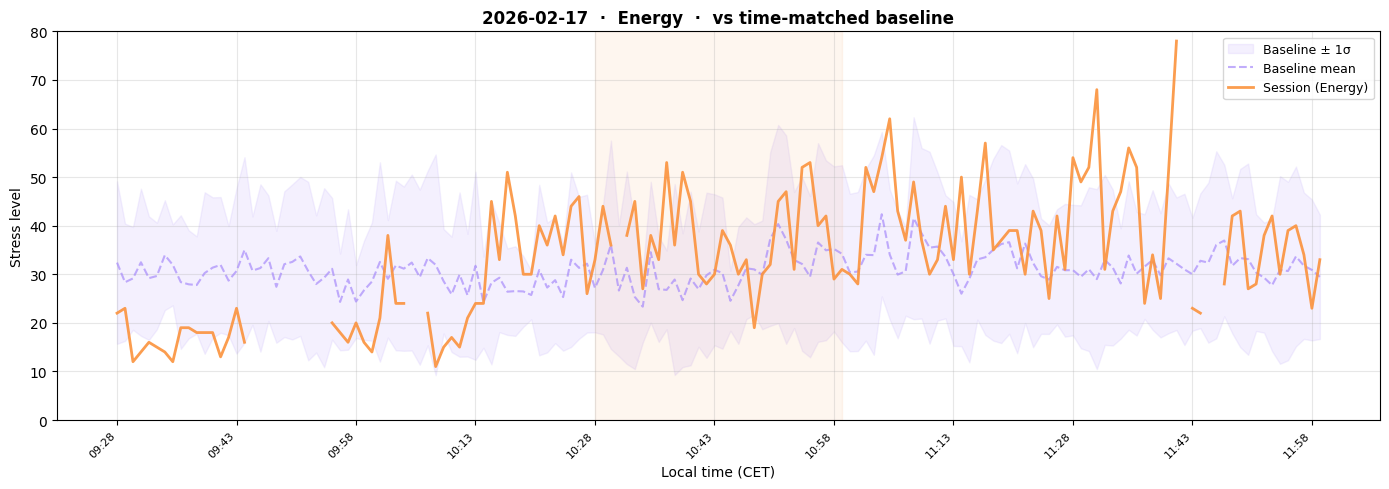

In [30]:
def plot_vs_baseline(traces_df, stress_full_df, session_date, utc_offset=1):
    """Overlay a session trace with the time-matched non-session baseline."""
    t = traces_df[traces_df["session_date"] == session_date].copy()
    if t.empty:
        return

    playlist = t["playlist"].iloc[0]
    pl_color = ENERGY_CLR if playlist == "Energy" else CALM_CLR

    # Get the UTC timestamps of this session window
    t_utc = pd.to_datetime(t["timestamp_utc"])
    hour_start = t_utc.iloc[0].hour
    hour_end = t_utc.iloc[-1].hour

    # Pull same time-of-day from non-session days
    baseline_days = stress_full_df[~stress_full_df["is_session_day"]].copy()
    baseline_days["minute_of_day"] = (baseline_days["timestamp"].dt.hour * 60
                                       + baseline_days["timestamp"].dt.minute)

    session_minutes = t_utc.dt.hour * 60 + t_utc.dt.minute
    min_minute = session_minutes.min()
    max_minute = session_minutes.max()

    bl = baseline_days[baseline_days["minute_of_day"].between(min_minute, max_minute)]

    # Aggregate baseline by minute-of-day
    bl_grouped = bl.groupby("minute_of_day")["stress"].agg(["mean", "std", "count"])

    # Align: convert session to minute-of-day for x-axis matching
    t["minute_of_day"] = t_utc.dt.hour * 60 + t_utc.dt.minute

    fig, ax = plt.subplots(figsize=(14, 5))

    # Baseline band
    ax.fill_between(bl_grouped.index, bl_grouped["mean"] - bl_grouped["std"],
                    bl_grouped["mean"] + bl_grouped["std"],
                    color="#a78bfa", alpha=0.12, label="Baseline ± 1σ")
    ax.plot(bl_grouped.index, bl_grouped["mean"], color="#a78bfa", lw=1.5,
            ls="--", alpha=0.7, label="Baseline mean")

    # Session trace
    ax.plot(t["minute_of_day"].values, t["stress"].values, color=pl_color,
            lw=2, alpha=0.9, label=f"Session ({playlist})")

    # Mark playlist window
    during = t[t["phase"] == "during"]["minute_of_day"]
    if len(during):
        ax.axvspan(during.min(), during.max(), alpha=0.08, color=pl_color)

    # Format x-axis as clock times (local)
    tick_positions = range(min_minute, max_minute + 1, 15)
    tick_labels = [f"{(m // 60 + utc_offset) % 24:02d}:{m % 60:02d}" for m in tick_positions]
    ax.set_xticks(list(tick_positions))
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45, ha="right")

    ax.set_xlabel("Local time (CET)")
    ax.set_ylabel("Stress level")
    ax.set_title(f"{session_date}  ·  {playlist}  ·  vs time-matched baseline", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 80)
    plt.tight_layout()
    plt.show()

# Show for each session
for date in dates:
    plot_vs_baseline(traces, stress_full, date)

## 13. How far from normal?

For each session: during-session stress minus the time-matched non-session baseline.  
Positive = more stressed than usual at that time. Negative = calmer than usual.

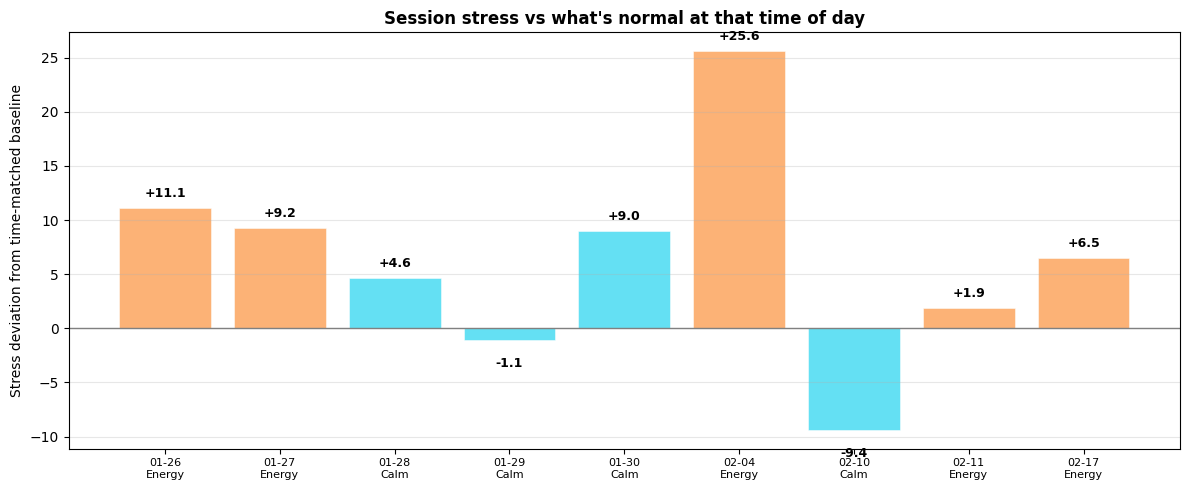


Interpretation:
  Energy sessions: +10.9 avg deviation from baseline
  Calm sessions:   +0.8 avg deviation from baseline


In [31]:
deviations = []

non_sess = stress_full[~stress_full["is_session_day"]].copy()
non_sess["minute_of_day"] = non_sess["timestamp"].dt.hour * 60 + non_sess["timestamp"].dt.minute
bl_by_minute = non_sess.groupby("minute_of_day")["stress"].mean()

for _, r in s.iterrows():
    t = traces[traces["session_date"] == r["date"]].copy()
    t_utc = pd.to_datetime(t["timestamp_utc"])
    during = t[t["phase"] == "during"].copy()
    during_utc = pd.to_datetime(during["timestamp_utc"])
    during["mod"] = during_utc.dt.hour * 60 + during_utc.dt.minute

    # Match each session minute to its baseline
    matched_bl = during["mod"].map(bl_by_minute)
    session_mean = during["stress"].mean()
    baseline_mean = matched_bl.mean()

    if not np.isnan(session_mean) and not np.isnan(baseline_mean):
        deviations.append({
            "date": r["date"],
            "playlist": r["playlist"],
            "session_stress": session_mean,
            "baseline_stress": baseline_mean,
            "deviation": session_mean - baseline_mean,
        })

dev_df = pd.DataFrame(deviations)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [ENERGY_CLR if p == "Energy" else CALM_CLR for p in dev_df["playlist"]]
bars = ax.bar(range(len(dev_df)), dev_df["deviation"], color=colors, alpha=0.7,
              edgecolor="white", lw=0.5)
ax.axhline(0, color="grey", lw=1)
ax.set_xticks(range(len(dev_df)))
ax.set_xticklabels([f"{r['date'][5:]}\n{r['playlist']}" for _, r in dev_df.iterrows()], fontsize=8)
ax.set_ylabel("Stress deviation from time-matched baseline")
ax.set_title("Session stress vs what's normal at that time of day", fontweight="bold")

for i, v in enumerate(dev_df["deviation"]):
    ax.text(i, v + (1 if v >= 0 else -2.5), f"{v:+.1f}", ha="center", fontsize=9, fontweight="bold")

ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Energy sessions: {dev_df[dev_df['playlist']=='Energy']['deviation'].mean():+.1f} avg deviation from baseline")
print(f"  Calm sessions:   {dev_df[dev_df['playlist']=='Calm']['deviation'].mean():+.1f} avg deviation from baseline")

## 14. Full distribution: session days vs rest days

Stress histograms for session windows vs the same time-of-day on non-session days.  
If the distributions differ, the music is shifting the participant's physiological state  
away from their natural pattern.

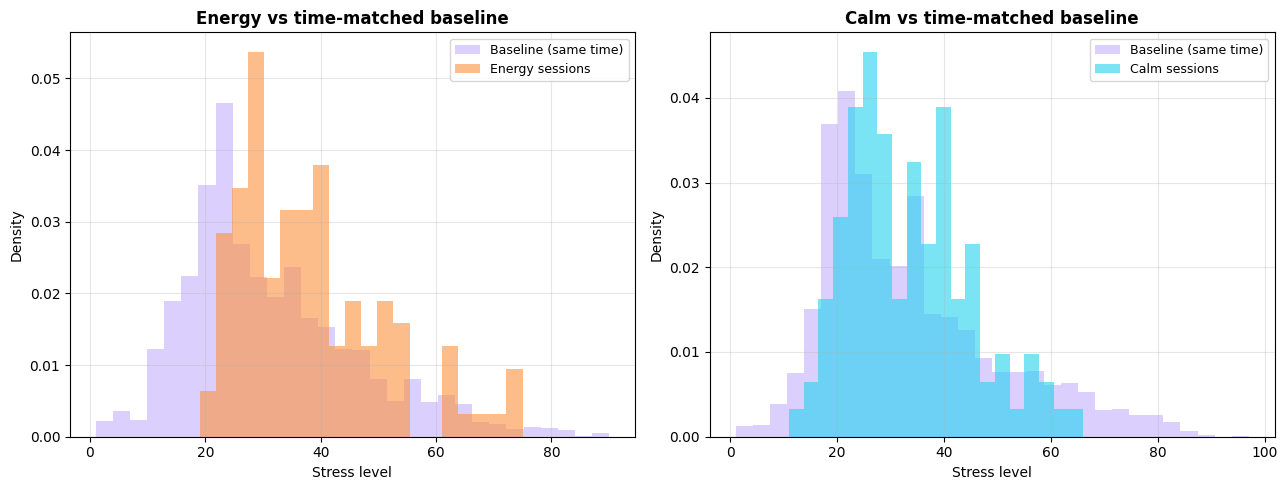

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (playlist, color) in zip(axes, [("Energy", ENERGY_CLR), ("Calm", CALM_CLR)]):
    # Collect during-session stress
    pl_traces = traces[(traces["playlist"] == playlist) & (traces["phase"] == "during")]
    session_stress = pl_traces["stress"].dropna()

    # Collect time-matched baseline stress
    bl_stress = []
    for date in pl_traces["session_date"].unique():
        t = traces[traces["session_date"] == date]
        t_utc = pd.to_datetime(t[t["phase"] == "during"]["timestamp_utc"])
        if t_utc.empty:
            continue
        min_m = t_utc.dt.hour.min() * 60 + t_utc.dt.minute.min()
        max_m = t_utc.dt.hour.max() * 60 + t_utc.dt.minute.max()
        bl = non_sess[non_sess["minute_of_day"].between(min_m, max_m)]["stress"].dropna()
        bl_stress.append(bl)

    if bl_stress:
        bl_all = pd.concat(bl_stress)
        ax.hist(bl_all, bins=30, alpha=0.4, color="#a78bfa", density=True, label="Baseline (same time)")
    ax.hist(session_stress, bins=20, alpha=0.6, color=color, density=True, label=f"{playlist} sessions")

    ax.set_xlabel("Stress level")
    ax.set_ylabel("Density")
    ax.set_title(f"{playlist} vs time-matched baseline", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()